<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_02_RNN_Radio_interactivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación por vecinos dentro de un radio
El clasificador conserva los ejemplos de entrenamiento y vota entre los vecinos situados a una distancia menor o igual al radio. El radio es un hiperparámetro: determina el tamaño del vecindario; el número de vecinos puede cambiar para cada consulta.

Usamos datos simulados de niños y adultos, estatura y peso, distancia euclidiana y votos ponderados por distancia. Aquí RNN significa vecinos dentro de un radio, no red neuronal recurrente.


Text(0, 0.5, 'Peso en kilogramos')

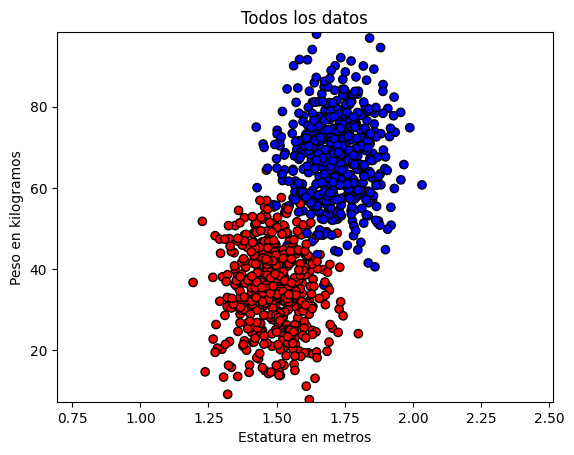

In [1]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X, y = make_blobs(n_samples=[500,500],
                  n_features = 2,
                  centers=[[1.49,35],[1.72,67]],
                  cluster_std = [[0.1,10],[0.1,10]],
                  random_state=1970)

x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura en metros")
plt.ylabel("Peso en kilogramos")

El ejemplo lo basaremos en datos simulados que representan\
una población de personas de género masculino\
niños y adultos, y se tienen dos características de ellos: estatura y peso

Dado que las escalas de peso y estaturas son muy diferentes
(dos ordenes de magnitud)
Antes de aplicar el clasificador, debemos llevarlas
a la misma escala:
* Se resta la media
* Se divide por la desviación estándar


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_original = X.copy()
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original, y, test_size=0.33, random_state=1970)
escalador = StandardScaler()
X_train = escalador.fit_transform(X_train_original)
X_test = escalador.transform(X_test_original)
X = escalador.transform(X_original)
X_estandarizada = X


Y volvemos a mostrar los datos ...

Text(0, 0.5, 'Peso estandarizado')

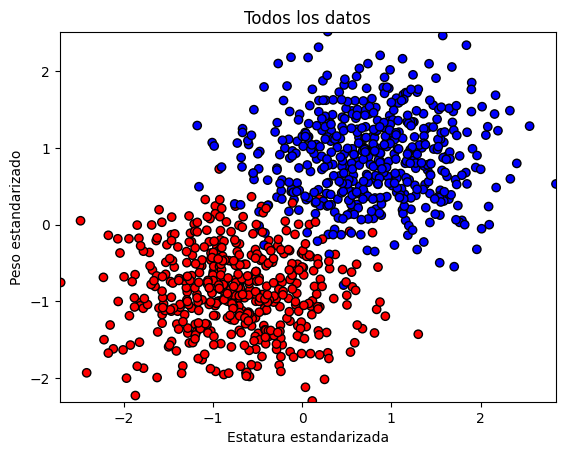

In [3]:
x_min, x_max = X[:, 0].min() - .01, X[:, 0].max() + .01
y_min, y_max = X[:, 1].min() - .01, X[:, 1].max() + .01
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura estandarizada")
plt.ylabel("Peso estandarizado")


La separación se realizó antes de estandarizar para evitar que la prueba influya en la media y la desviación.


In [4]:
# La separación se realizó antes de ajustar el escalador.
print(f'Entrenamiento: {len(y_train)}; prueba: {len(y_test)}')


Entrenamiento: 670; prueba: 330


In [5]:
np.unique(y)

array([0, 1])

In [6]:
from sklearn import neighbors
clfRNN = neighbors.RadiusNeighborsClassifier(radius=0.6, # radio en unidades estandarizadas
                                        weights='distance', # pesos asignados a los vecinos al momento
                                                           # de tomar la decisión
                                                           # 'uniform', 'distance'
                                        algorithm='brute', # optimiza la ejecución del clasificador
                                                           # ‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’
                                        p=2, # usado para la fórmula de la distancia de Minkowski
                                        metric='minkowski',
                                        outlier_label=0
                                        #outlier_label='most_frequent'
                                        )
clfRNN.fit(X_train,y_train)
y_esperado = y_test
y_predicho = clfRNN.predict(X_test)


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
print(accuracy_score(y_esperado,y_predicho))
print(recall_score(y_esperado,y_predicho))
print(precision_score(y_esperado,y_predicho))
print(confusion_matrix(y_esperado,y_predicho))

0.9727272727272728
0.9644970414201184
0.9819277108433735
[[158   3]
 [  6 163]]


Las métricas anteriores corresponden al radio inicial de 0.6. Más abajo se exploran otros radios usando únicamente el conjunto de entrenamiento.


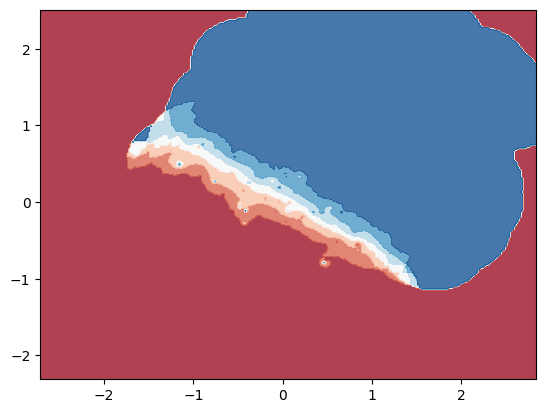

In [8]:
Z = clfRNN.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8)

La figura anterior representa la probabilidad de adulto. Con `outlier_label=0`, los puntos sin vecinos reciben la clase niño por defecto. Esto es una regla de respaldo, no evidencia de que sean niños. La gráfica interactiva distinguirá esas zonas en gris.


## 1. Métricas frente al radio: validación cruzada
Se evalúan radios de **0.10 a 3.00**, en pasos de **0.10**, con cinco particiones estratificadas del entrenamiento. El escalador se ajusta dentro de cada partición. El conjunto de prueba se reserva para evaluación final.

Se conserva `outlier_label=0` del ejemplo: **todas las métricas incluyen esa asignación a niño cuando no hay vecinos**. En particular, probabilidades extremas incorrectas pueden aumentar mucho Log loss. La cobertura indica la fracción de consultas con al menos un vecino; debe interpretarse junto con las métricas.

Accuracy, F1 (adulto = 1), ROC-AUC y Kappa: mayor es mejor. Log loss y Brier binario: menor es mejor. Las bandas son media ± una desviación estándar entre particiones, no intervalos de confianza. Los ejes verticales se ajustan para mostrar diferencias pequeñas.


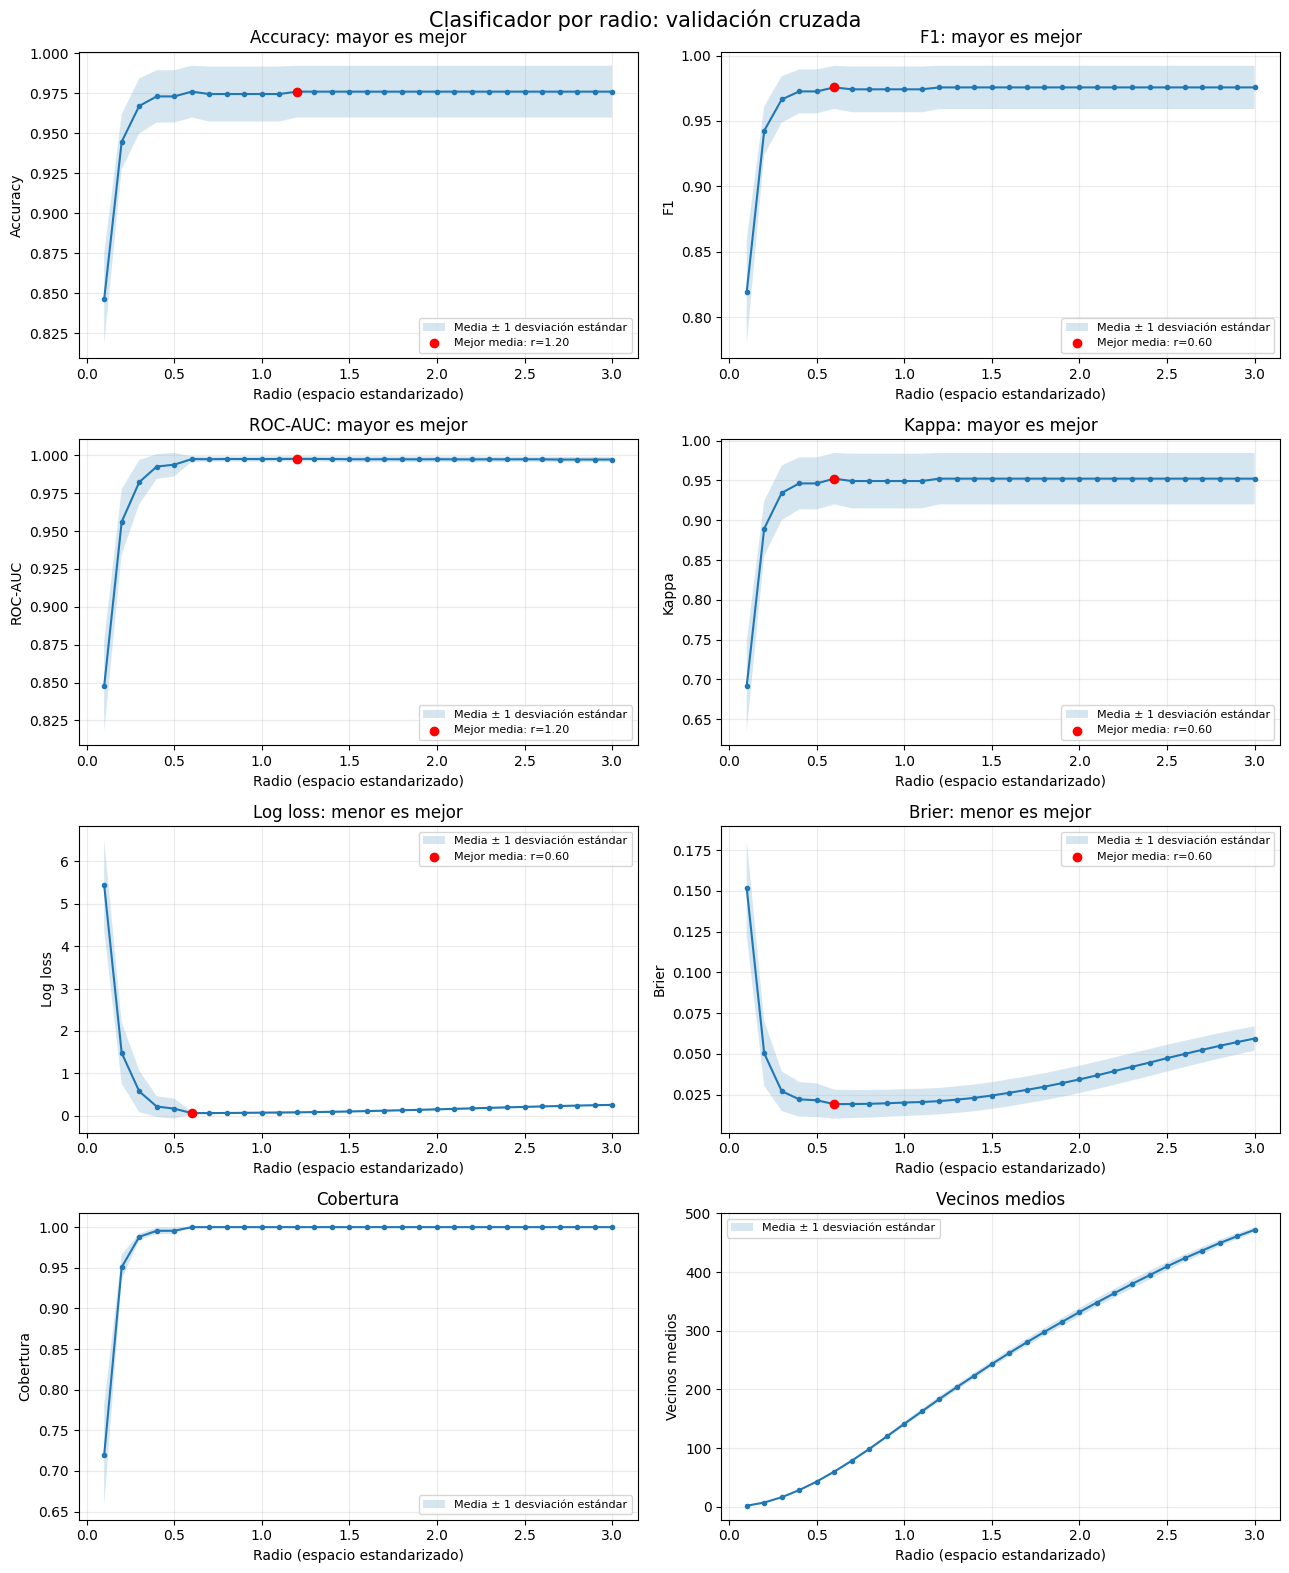

Radios con mejor media (primer radio si hay empate exacto):
Accuracy  : r=1.20, media=0.976119, cobertura=100.00%
F1        : r=0.60, media=0.975663, cobertura=100.00%
ROC-AUC   : r=1.20, media=0.997638, cobertura=100.00%
Kappa     : r=0.60, media=0.952229, cobertura=100.00%
Log loss  : r=0.60, media=0.064297, cobertura=100.00%
Brier     : r=0.60, media=0.019156, cobertura=100.00%


In [9]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             log_loss, cohen_kappa_score)

radios = np.round(np.arange(0.1, 3.01, 0.1), 2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1970)
nombres = ['Accuracy', 'F1', 'ROC-AUC', 'Kappa', 'Log loss',
           'Brier', 'Cobertura', 'Vecinos medios']
resultados_radio = {nombre: np.zeros((len(radios), 5)) for nombre in nombres}

for fold, (it, iv) in enumerate(cv.split(X_train_original, y_train)):
    scaler_cv = StandardScaler()
    xt = scaler_cv.fit_transform(X_train_original[it])
    xv = scaler_cv.transform(X_train_original[iv])
    yt, yv = y_train[it], y_train[iv]
    for j, radio in enumerate(radios):
        modelo = clone(clfRNN).set_params(radius=float(radio))
        modelo.fit(xt, yt)
        pred = modelo.predict(xv)
        probabilidades = modelo.predict_proba(xv)
        p1 = probabilidades[:, np.flatnonzero(modelo.classes_ == 1).item()]
        vecinos = modelo.radius_neighbors(xv, return_distance=False)
        cantidades = np.array([len(v) for v in vecinos])
        valores = [accuracy_score(yv, pred),
                   f1_score(yv, pred, zero_division=0),
                   roc_auc_score(yv, p1), cohen_kappa_score(yv, pred),
                   log_loss(yv, probabilidades, labels=modelo.classes_),
                   np.mean((p1 - yv)**2),
                   np.mean(cantidades > 0), cantidades.mean()]
        for nombre, valor in zip(nombres, valores):
            resultados_radio[nombre][j, fold] = valor

fig, axes = plt.subplots(4, 2, figsize=(13, 16), sharex=True)
for ax, nombre in zip(axes.ravel(), nombres):
    valores = resultados_radio[nombre]
    media = valores.mean(axis=1)
    sd = valores.std(axis=1, ddof=1)
    ax.plot(radios, media, 'o-', markersize=3)
    ax.fill_between(radios, media-sd, media+sd, alpha=0.18,
                    label='Media ± 1 desviación estándar')
    if nombre not in ['Cobertura', 'Vecinos medios']:
        menor = nombre in ['Log loss', 'Brier']
        mejor = np.argmin(media) if menor else np.argmax(media)
        ax.scatter(radios[mejor], media[mejor], color='red', zorder=5,
                   label=f'Mejor media: r={radios[mejor]:.2f}')
        direccion = 'menor es mejor' if menor else 'mayor es mejor'
        ax.set_title(f'{nombre}: {direccion}')
    else:
        ax.set_title(nombre)
    ax.set(xlabel='Radio (espacio estandarizado)', ylabel=nombre)
    ax.tick_params(labelbottom=True)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle('Clasificador por radio: validación cruzada', fontsize=15)
fig.tight_layout()
plt.show()

print('Radios con mejor media (primer radio si hay empate exacto):')
for nombre in nombres[:6]:
    medias = resultados_radio[nombre].mean(axis=1)
    j = np.argmin(medias) if nombre in ['Log loss', 'Brier'] else np.argmax(medias)
    cobertura = resultados_radio['Cobertura'][j].mean()
    print(f'{nombre:10s}: r={radios[j]:.2f}, media={medias[j]:.6f}, cobertura={cobertura:.2%}')


En el clasificador basado en radio, cada muestra puede tener un número diferente de vecinos, incluso ninguno.

Para una muestra $x_i$, definimos:

$$ n_i(r)=\text{número de ejemplos de entrenamiento a distancia }\leq r $$

Cobertura

Es el porcentaje de muestras evaluadas que tienen al menos un vecino dentro del radio:

$$ \boxed{ \text{Cobertura}(r)= \frac{\text{muestras con al menos un vecino}}{\text{total de muestras evaluadas}} \times 100\% } $$

Una cobertura del 95 % significa que el clasificador encuentra vecinos para 95 de cada 100 muestras. Las otras 5 requieren una regla de respaldo.

En tu cuaderno, outlier_label=0 asigna esas muestras a niño, aunque no existan vecinos que sustenten esa decisión. Cobertura no significa porcentaje de aciertos.

Vecinos medios

Es el promedio del número de vecinos encontrados por muestra, incluyendo las que tienen cero vecinos:

$$ \boxed{ \text{Vecinos medios}(r)=\frac{1}{N}\sum_{i=1}^{N}n_i(r) } $$

Por ejemplo:

Muestra evaluada	|Vecinos dentro del radio
|---|---|
A	|0
B	|2
C	|5
D	|0
E |3

Entonces:

$$ \text{Cobertura}=\frac{3}{5}\times100\%=60\% $$ $$ \text{Vecinos medios}=\frac{0+2+5+0+3}{5}=2 $$

¿Cómo ayudan a elegir el radio?

Radio	|Cobertura y vecinos	|Posible efecto
|---|---|---|
Pequeño	|Pocos vecinos; puede haber muestras sin vecinos	|Decisiones sensibles a ejemplos individuales y mayor uso del respaldo
Intermedio	|Mayor cobertura y vecindarios locales	|Puede ofrecer un buen equilibrio
Grande	|Muchos vecinos; cobertura cercana al 100 %	|Puede mezclar clases y perder detalle local

Con los mismos datos, ambas cantidades solo pueden aumentar o permanecer iguales al ampliar el radio. Sin embargo, el desempeño de clasificación puede empeorar.

En el cuaderno, estas medidas se calculan sobre las muestras de validación de cada partición, buscando vecinos únicamente en su entrenamiento. Las gráficas muestran el promedio entre las cinco particiones.

La cobertura permite saber cuántas decisiones tienen vecinos disponibles; los vecinos medios indican cuántos ejemplos participan, en promedio, en cada decisión. Como usas weights='distance', esos vecinos no tienen todos la misma influencia.

## 2. Espacio de clasificación interactivo
El deslizador cambia el radio de 0.10 a 3.00, en pasos de 0.05. Rojo: niño; azul: adulto; gris: sin vecinos (el modelo asigna niño por respaldo). Los puntos son ejemplos de entrenamiento. El círculo ilustra un vecindario del radio seleccionado, centrado en el origen del espacio estandarizado; no es una frontera de clase.

Use las métricas de validación cruzada para elegir el radio; esta vista ilustra las regiones y los ejemplos de entrenamiento sin consultar el conjunto de prueba.

Ejecute las celdas en orden con un kernel activo. Si falta la dependencia, ejecute `%pip install ipywidgets`. La gráfica cambia al soltar el deslizador. En Colab se habilita su gestor de widgets automáticamente.


In [10]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Patch, Circle
try:
    from google.colab import output as salida_colab
except ImportError:
    pass
else:
    salida_colab.enable_custom_widget_manager()

# Extensión fijada a partir del entrenamiento; no cambia con el radio.
gx = np.linspace(X_train[:, 0].min()-.4, X_train[:, 0].max()+.4, 120)
gy = np.linspace(X_train[:, 1].min()-.4, X_train[:, 1].max()+.4, 120)
mx, my = np.meshgrid(gx, gy)
consultas = np.c_[mx.ravel(), my.ravel()]

from functools import lru_cache
@lru_cache(maxsize=60)
def calcular_regiones(radio):
    modelo = clone(clfRNN).set_params(radius=float(radio)).fit(X_train, y_train)
    regiones = modelo.predict(consultas).astype(int)
    # En bloques para limitar la memoria si el radio contiene muchos vecinos.
    for inicio in range(0, len(consultas), 1000):
        v = modelo.radius_neighbors(consultas[inicio:inicio+1000], return_distance=False)
        sin_vecinos = np.array([len(a) == 0 for a in v])
        indices = inicio + np.flatnonzero(sin_vecinos)
        regiones[indices] = -1
    return regiones.reshape(mx.shape)

def mostrar_radio(radio):
    regiones = calcular_regiones(round(radio, 2))
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.contourf(mx, my, regiones, levels=[-1.5, -.5, .5, 1.5],
                cmap=ListedColormap(['#dddddd', '#f7c6c6', '#c4dcf4']))
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap=ListedColormap(['#d62728', '#1765ad']),
               s=12, edgecolors='white', linewidths=.2)
    ax.add_patch(Circle((0, 0), radio, fill=False, color='black', linestyle='--'))
    ax.scatter([0], [0], marker='+', color='black')
    ax.set(xlabel='Estatura estandarizada', ylabel='Peso estandarizado',
           title=f'Regiones de clasificación | radio = {radio:.2f}',
           xlim=(gx[0], gx[-1]), ylim=(gy[0], gy[-1]))
    ax.set_aspect('equal', adjustable='box')
    ax.legend(handles=[Patch(color='#dddddd', label='Sin vecinos: respaldo clase 0'),
                       Patch(color='#f7c6c6', label='Niños (0)'),
                       Patch(color='#c4dcf4', label='Adultos (1)'),
                       Patch(fill=False, linestyle='--', label='Vecindario ilustrativo')],
              fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

barra_radio = widgets.FloatSlider(value=0.6, min=0.1, max=3.0, step=0.05,
                                  description='Radio:', readout_format='.2f',
                                  continuous_update=False,
                                  layout=widgets.Layout(width='650px'))
salida_radio = widgets.interactive_output(mostrar_radio, {'radio': barra_radio})
display(widgets.VBox([barra_radio, salida_radio]))


## Cómo estimar el radio
1. Examine la cobertura: un radio muy pequeño puede dejar muchas consultas sin vecinos.
2. Compare Log loss y Brier junto con F1, ROC-AUC y Kappa. Elija el criterio según su objetivo, no por cuál arroje un valor más atractivo.
3. Prefiera una zona estable de buen desempeño; pequeñas diferencias entre medias no garantizan una mejora real.
4. Una vez fijado el radio, ajuste el modelo con todo el entrenamiento y evalúe una sola vez sobre la prueba. Si cambia la regla de respaldo, repita la validación: sus métricas también pueden cambiar.
